In [135]:
# Libraries
# scipy, numpy, pandas, matplotlib, seaborn and scikit-learn

from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris # dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# parameter tuning
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler


# Additional libraries

from sklearn.tree import DecisionTreeClassifier # Decision Tree
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier # Random Forest

from sklearn import svm # SVM 
from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier # KNN

from sklearn.naive_bayes import GaussianNB #NB

In [136]:
iris = load_iris(as_frame= True)
X_values = iris.data
y_values = iris.target


In [137]:
class DataPrep:
    def __init__(self, test_size = 0.20, validation_size = 0.20, random_state = 123):
        self.test_size = test_size
        self.validation_size = validation_size
        self.random_state = random_state

        self.scaler = StandardScaler()

        self.X_train, self.X_test, self.X_val = None, None, None
        self.y_train, self.y_test, self.y_val = None, None, None
        self.X_train_scaled, self.X_test_scaled, self.X_val_scaled = None, None, None
        
        self.X_combined, self.X_combined_scaled, self.y_combined = None, None, None
 
    def split(self, X_values, y_values):
        X_temp, self.X_test, y_temp, self.y_test = train_test_split(X_values, 
                                                                    y_values, 
                                                                    test_size = self.test_size, 
                                                                    random_state=self.random_state)
        adj_val_size = self.validation_size / (1.0 - self.test_size)
        self.X_train, self.X_val, self.y_train, self.y_val = train_test_split(X_temp,
                                                                              y_temp,
                                                                              test_size=adj_val_size,
                                                                              random_state=self.random_state)
        return self

    def transform(self):
        self.X_train_scaled = self.scaler.fit_transform(self.X_train)
        self.X_test_scaled = self.scaler.transform(self.X_test)
        self.X_val_scaled = self.scaler.transform(self.X_val)
        return self

    def combine(self):
        self.X_combined = np.vstack([self.X_train, self.X_val])
        self.y_combined = np.concatenate([self.y_train, self.y_val])
        return self

    def combine_scaled(self):
        self.X_combined_scaled = np.vstack([self.X_train_scaled, self.X_val_scaled])
        self.y_combined = np.concatenate([self.y_train, self.y_val])
        return self


In [138]:
data = DataPrep()
data.split(X_values, y_values).transform()
data.split(X_values, y_values).transform().combine_scaled()
data.split(X_values, y_values).transform().combine()



In [139]:
print(data.X_train.shape[0])
print(data.y_train.shape[0])
print(data.X_test.shape[0])
print(data.y_test.shape[0])
print(data.X_val.shape[0])
print(data.y_val.shape[0])

90
90
30
30
30
30


### Exploratory Data Analysis

In [140]:
data = DataPrep(test_size=0.20, validation_size=0.20, random_state=123)
data.split(X_values, y_values)
data.transform()
data.combine()
data.combine_scaled()

# PredefinedSplit to use validation set in grid search

def val_split_idxs(X_train, X_combined):
    split_index = np.zeros(X_combined.shape[0]) 
    split_index[:len(X_train)] = -1           
    split_index[len(X_train):] = 0 # Mark validation samples with 0
    return PredefinedSplit(test_fold=split_index)

pds = val_split_idxs(data.X_train, data.X_combined)


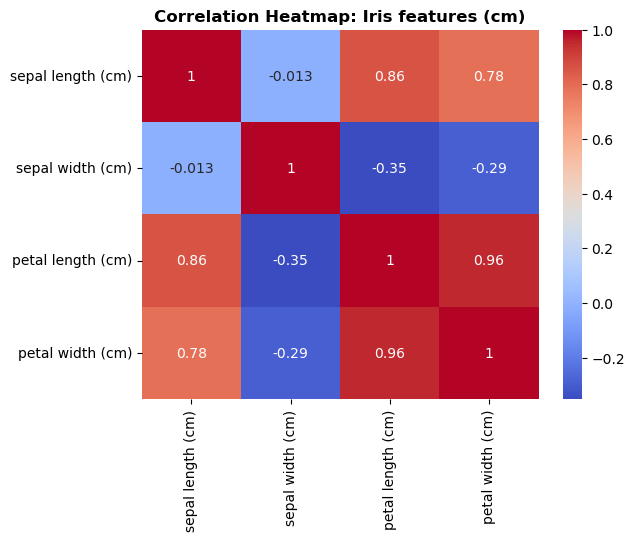

In [165]:
correlation_matrix = data.X_train.corr(numeric_only =True)
sns.heatmap(correlation_matrix, cmap= "coolwarm", annot= True)
plt.title("Correlation Heatmap: Iris features (cm)", fontsize=12, fontweight='bold')
plt.show()

### Decision Tree

In [142]:
dt_m = DecisionTreeClassifier(random_state=123)

dt_m.fit(data.X_train, data.y_train)
val_preds = dt_m.predict(data.X_val)
val_accuracy = accuracy_score(data.y_val, val_preds)
print(f"Decision Tree Baseline Validation Accuracy: {val_accuracy * 100:.4f}%")


df_param = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10]
}
metrics = ['accuracy', 'f1_macro']
dt_search = GridSearchCV(
    estimator=dt_m, 
    param_grid=df_param, 
    cv=pds, 
    scoring= metrics,
    refit = 'accuracy',
    n_jobs=-1
)

dt_search.fit(data.X_combined, data.y_combined)

print("Best Hyperparameters:", dt_search.best_params_)
print(f"Best Validation Accuracy: {dt_search.best_score_ * 100:.4f}%")

Decision Tree Baseline Validation Accuracy: 96.6667%
Best Hyperparameters: {'criterion': 'gini', 'max_depth': 3}
Best Validation Accuracy: 96.6667%


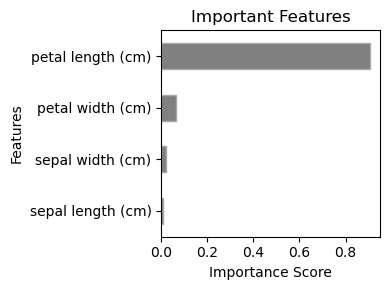

In [143]:
unsorted_importances = pd.Series(dt_m.feature_importances_, index=iris.feature_names)
sorted_importances = unsorted_importances.sort_values(ascending=True)

plt.figure(figsize=(4, 3))
sorted_importances.plot(kind = 'barh', color = 'grey', edgecolor='darkgrey' )
plt.title('Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


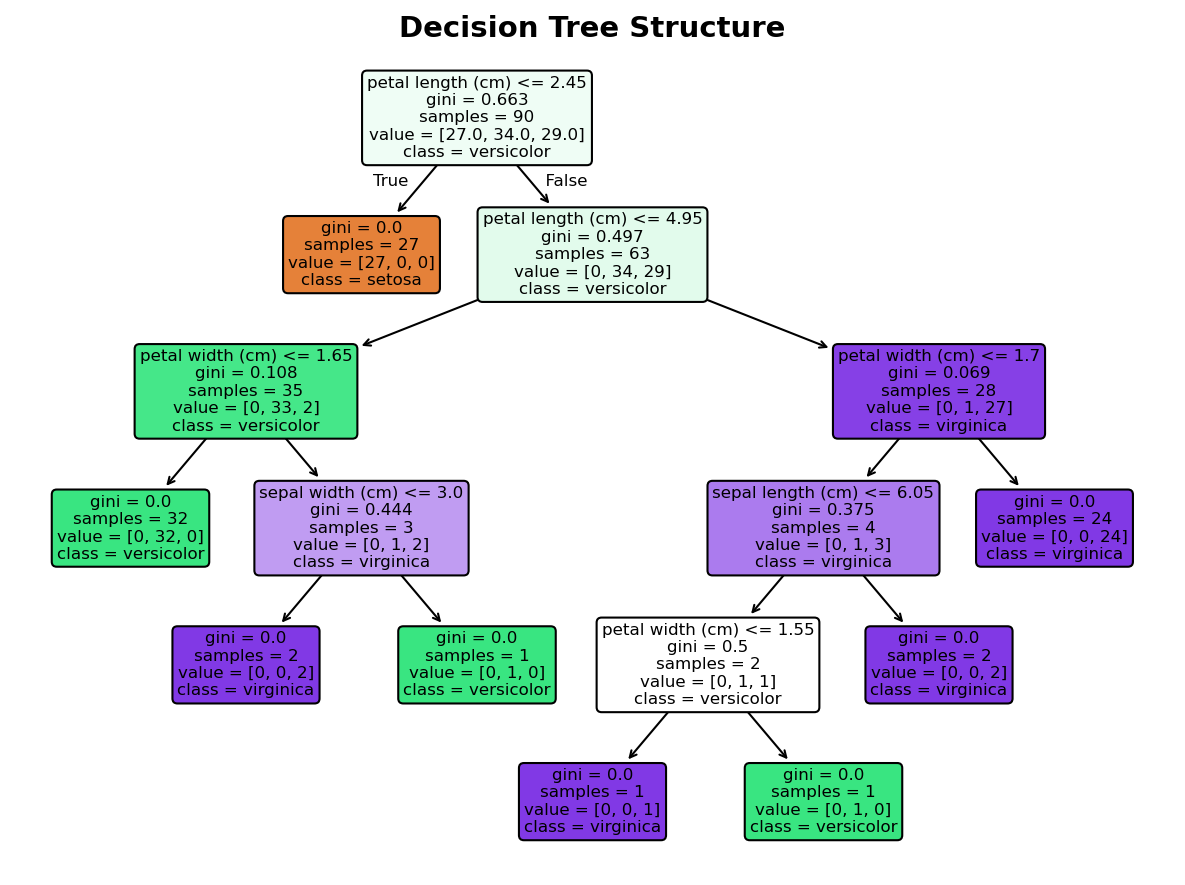

In [144]:

plt.figure(figsize=(8, 6), dpi=150)

plot_tree(
    dt_m,
    feature_names=iris.feature_names, 
    class_names=iris.target_names,    
    filled=True,                      
    rounded=True,                     
    fontsize=8                      
)

plt.title('Decision Tree Structure', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Support Vector Machine

In [145]:
# SVM

svm_m = SVC(random_state = 123, probability=True)
svm_m.fit(data.X_train_scaled, data.y_train)
val_preds = svm_m.predict(data.X_val_scaled)
val_accuracy = accuracy_score(data.y_val, val_preds)
print(f"SVM Baseline Validation Accuracy: {val_accuracy * 100:.4f}%")
# SVM - Hyper parameter tuning

svm_param = [{'kernel': ['linear'], 'C': [0.1, 1.0, 10]},
                 {'kernel': ['rbf'],'C': [0.1, 1.0, 10.0], 'gamma': ['auto', 'scale', 0.01, 0.1] }]
metrics = ['accuracy', 'f1_macro']
svm_search = GridSearchCV(
    estimator=svm_m, 
    param_grid=svm_param, 
    cv=pds, 
    scoring= metrics,
    refit = 'accuracy',
    n_jobs=-1
)

svm_search.fit(data.X_combined_scaled, data.y_combined)

print(f"Best Hyperparameters: {svm_search.best_params_}")
print(f"Best Validation Accuracy: {svm_search.best_score_ * 100:.4f}%")

SVM Baseline Validation Accuracy: 96.6667%
Best Hyperparameters: {'C': 0.1, 'kernel': 'linear'}
Best Validation Accuracy: 96.6667%


### Random Forest

In [146]:
rf_m = RandomForestClassifier(random_state=123)
rf_m.fit(data.X_train, data.y_train)
val_preds = rf_m.predict(data.X_val)
val_accuracy = accuracy_score(data.y_val, val_preds)

print(f"Random Forest Baseline Validation Accuracy: {val_accuracy * 100:.4f}%")

# parameter grid for random forest
rf_param = {
    'max_depth': [1, 5, 10, 15],
    'min_samples_split': [2, 3, 4, 5]
}

# GridSearchCV using with predefined split for random forest
metrics = ['accuracy', 'f1_macro']
rf_search = GridSearchCV(
    estimator=rf_m,
    param_grid=rf_param,
    cv=pds,
    scoring=metrics,
    refit = 'accuracy',
    n_jobs=-1
)

# Fit on the combined dataset
rf_search.fit(data.X_combined, data.y_combined)

# Output results
print(f"Best Parameters: {rf_search.best_params_}")
print(f"Best Validation Score: {rf_search.best_score_*100:.4f}%")


Random Forest Baseline Validation Accuracy: 96.6667%
Best Parameters: {'max_depth': 5, 'min_samples_split': 2}
Best Validation Score: 96.6667%


### K-Nearest Neighbors

In [147]:

knn_m = KNeighborsClassifier()
knn_m.fit(data.X_train_scaled, data.y_train)
val_preds = knn_m.predict(data.X_val_scaled)
val_accuracy = accuracy_score(data.y_val, val_preds)

print(f"KNN Baseline Validation Accuracy: {val_accuracy * 100:.4f}%")


# KNN - Hyper parameter tuning

knn_param = [{
    'n_neighbors': [3,4,5],
    'metric': ['euclidean']
}]
metrics = ['accuracy', 'f1_macro']
knn_search = GridSearchCV(
    estimator=knn_m, 
    param_grid=knn_param, 
    cv= pds,
    scoring= metrics,
    refit = 'accuracy',
    n_jobs=-1
)

knn_search.fit(data.X_combined_scaled, data.y_combined)
print(f"Best Hyperparameters: {knn_search.best_params_}")
print(f"Best Validation Accuracy: {knn_search.best_score_ * 100:.2f}%")

KNN Baseline Validation Accuracy: 100.0000%
Best Hyperparameters: {'metric': 'euclidean', 'n_neighbors': 3}
Best Validation Accuracy: 100.00%


#### Naive Bayes

In [156]:
nb_m = GaussianNB()
nb_m.fit(data.X_train, data.y_train)
nb_val_preds = nb_m.predict(data.X_val)
nb_val_accuracy = accuracy_score(data.y_val, nb_val_preds)

print(f"Naive Bayes Baseline Validation Accuracy: {nb_val_accuracy * 100:.4f}%")

# smoothing points
nb_param = {"var_smoothing": np.logspace(0, -9, num = 100)}

metrics = ["accuracy", "f1_macro"]

nb_search = GridSearchCV(
    estimator=nb_m,
    param_grid=nb_param,
    cv=pds,
    scoring= metrics,
    refit="accuracy",
    n_jobs=-1,
)

nb_search.fit(data.X_combined, data.y_combined)

print(f"Best Parameters: {nb_search.best_params_}")
print(f"Best Validation Score: {nb_search.best_score_ * 100:.4f}%")


Naive Bayes Baseline Validation Accuracy: 96.6667%
Best Parameters: {'var_smoothing': np.float64(1.0)}
Best Validation Score: 96.6667%


### Evaluation of Models

In [149]:
# Evaluation on test data

# Decision Tree - final evaluation

best_dt_m = dt_search.best_estimator_
dt_test_preds = best_dt_m.predict(data.X_test)
dt_report = classification_report(data.y_test, dt_test_preds, target_names=iris.target_names)
 
# multiclass confusion matrix
dt_cm = confusion_matrix(data.y_test, dt_test_preds)


C:\Users\cathy\miniconda3\envs\catenv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


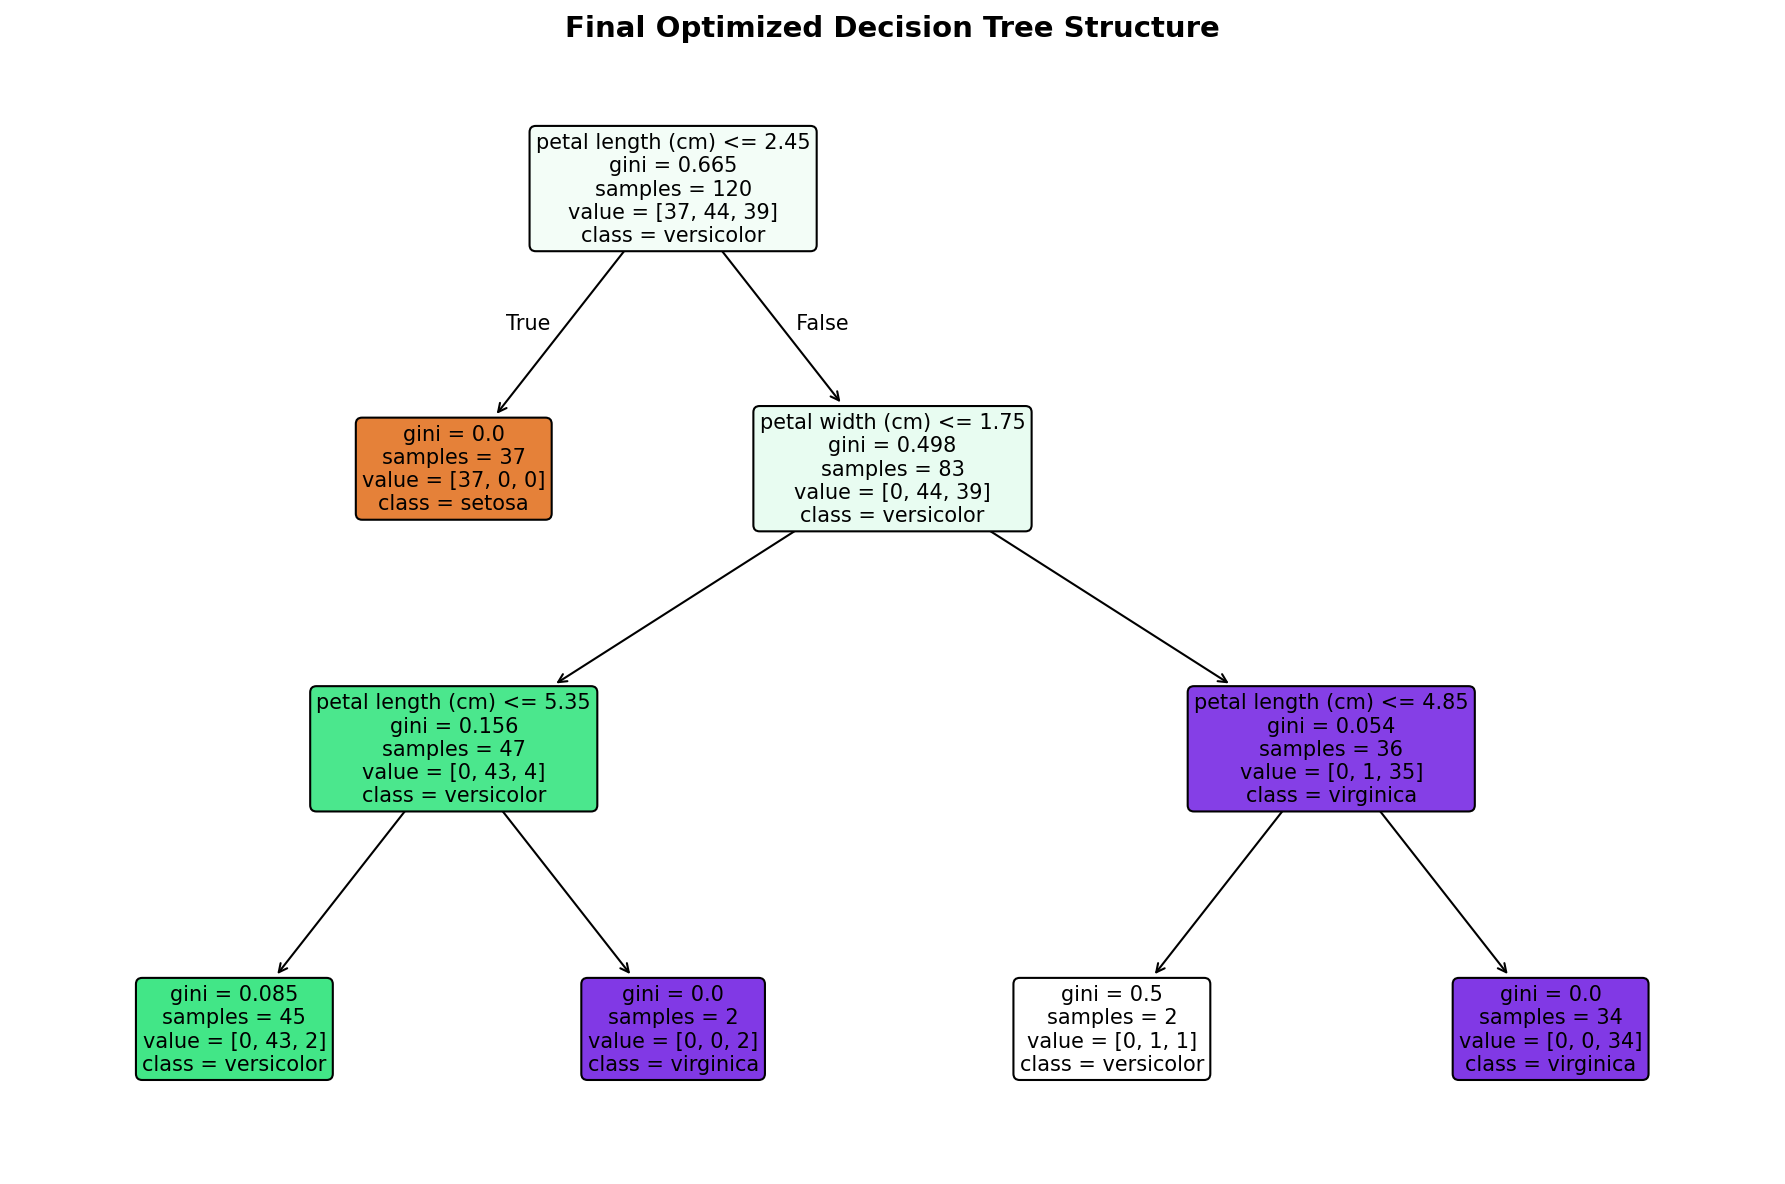

In [150]:
plt.figure(figsize=(12, 8), dpi=150)

plot_tree(
    best_dt_m,
    feature_names=iris.feature_names, 
    class_names=iris.target_names,
    filled=True, 
    rounded=True,
    fontsize=10
)

plt.title('Final Optimized Decision Tree Structure', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [151]:

best_svm_m = svm_search.best_estimator_

svm_test_preds = best_svm_m.predict(data.X_test_scaled)

svm_report = classification_report(data.y_test, svm_test_preds, target_names=iris.target_names)
 
# multiclass confusion matrix
svm_cm = confusion_matrix(data.y_test, svm_test_preds)


In [152]:
# Random Forest - final evaluation

best_rf_m = rf_search.best_estimator_

rf_test_preds = best_rf_m.predict(data.X_test)
rf_report = classification_report(data.y_test, rf_test_preds, target_names=iris.target_names)
 
# multiclass confusion matrix
rf_cm = confusion_matrix(data.y_test, rf_test_preds)


C:\Users\cathy\miniconda3\envs\catenv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [153]:
# KNN - final evaluation

best_knn_m = knn_search.best_estimator_
knn_test_preds = best_knn_m.predict(data.X_test_scaled)
knn_report = classification_report(data.y_test, knn_test_preds, target_names=iris.target_names)
 
# multiclass confusion matrix
knn_cm = confusion_matrix(data.y_test, knn_test_preds)



In [157]:
# NB - final evaluation

best_nb_m = nb_search.best_estimator_
nb_test_preds = best_nb_m.predict(data.X_test)
nb_report = classification_report(data.y_test, nb_test_preds, target_names=iris.target_names)
 
# multiclass confusion matrix
nb_cm = confusion_matrix(data.y_test, nb_test_preds)



C:\Users\cathy\miniconda3\envs\catenv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(


#### Confusion Matrices

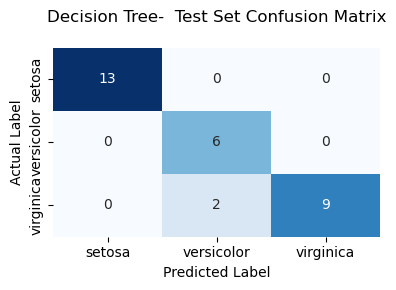

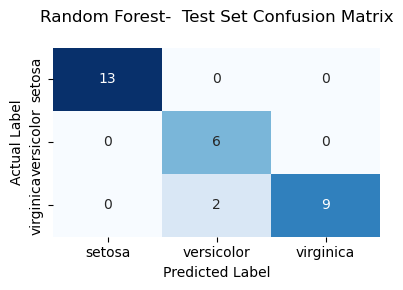

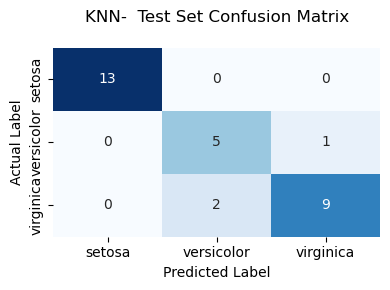

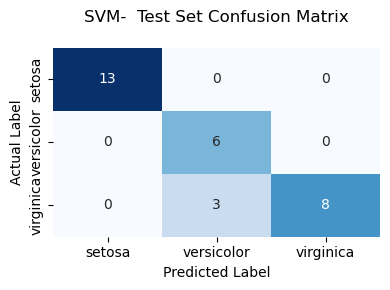

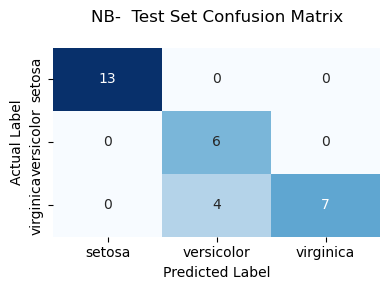

In [158]:
cm_objects = {
    'Decision Tree': dt_cm, 
    'Random Forest': rf_cm, 
    'KNN': knn_cm, 
    'SVM': svm_cm,
    'NB': nb_cm 
}
for model_name, cm_obj in cm_objects.items():
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm_obj, 
                annot=True, 
                fmt='d', 
                cmap='Blues', 
                cbar=False,
                xticklabels=iris.target_names,
                yticklabels=iris.target_names)
    plt.title(f"{model_name}-  Test Set Confusion Matrix\n")
    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Label')
    plt.tight_layout()
    plt.show()
    print("\n")

#### Hyperparameters

In [159]:
model_objects = {
    'Decision Tree': best_dt_m, 
    'Random Forest': best_rf_m, 
    'KNN': best_knn_m, 
    'SVM': best_svm_m,
    'NB': best_nb_m
}

model_params = []

for model_name, model_obj in model_objects.items():
    print(model_name, '\n')
    params = model_obj.get_params()
    print(params, '\n')
    model_params.append({
        "Model": model_name,
        "All Parameters": params
    })
df_model_params = pd.DataFrame(model_params)


Decision Tree 

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 3, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 123, 'splitter': 'best'} 

Random Forest 

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 123, 'verbose': 0, 'warm_start': False} 

KNN 

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'euclidean', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 3, 'p': 2, 'weights': 'uniform'} 

SVM 

{'C': 0.1, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'dec

#### Model Performance

In [160]:
search_objects = {
    'Decision Tree': dt_search, 
    'Random Forest': rf_search, 
    'KNN': knn_search, 
    'SVM': svm_search,
    'NB': nb_search
}
model_metrics = []

for model_name, search_obj in search_objects.items():
    best_model = search_obj.best_estimator_
    
    if model_name in ["SVM", "KNN"]:
        X_test_processed = data.X_test_scaled
    else:
        X_test_processed = data.X_test
        
    test_preds = best_model.predict(X_test_processed)
    test_acc = accuracy_score(data.y_test, test_preds)
    
    print(f"\n Model: {model_name} - Final Evaluation\n")
    print(classification_report(data.y_test, test_preds, target_names=iris.target_names))
    
    rep_dict = classification_report(data.y_test, test_preds, output_dict = True, target_names=iris.target_names)
    
    model_metrics.append({
        "Model": model_name,
        "Test Accuracy": f"{test_acc*100:.2f}%",
        "Precision (Macro)": f"{rep_dict['macro avg']['precision']*100:.2f}%",
        "Recall (Macro)": f"{rep_dict['macro avg']['recall']*100:.2f}%",
        "F1-Score (Macro)": f"{rep_dict['macro avg']['f1-score']*100:.2f}%"
    })


df_model = pd.DataFrame(model_metrics)
print(df_model[["Model", "Test Accuracy", "Precision (Macro)", "Recall (Macro)", "F1-Score (Macro)"]].to_string(index=False))



C:\Users\cathy\miniconda3\envs\catenv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\cathy\miniconda3\envs\catenv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(



 Model: Decision Tree - Final Evaluation

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       0.75      1.00      0.86         6
   virginica       1.00      0.82      0.90        11

    accuracy                           0.93        30
   macro avg       0.92      0.94      0.92        30
weighted avg       0.95      0.93      0.93        30


 Model: Random Forest - Final Evaluation

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       0.75      1.00      0.86         6
   virginica       1.00      0.82      0.90        11

    accuracy                           0.93        30
   macro avg       0.92      0.94      0.92        30
weighted avg       0.95      0.93      0.93        30


 Model: KNN - Final Evaluation

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicol

C:\Users\cathy\miniconda3\envs\catenv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(


C:\Users\cathy\miniconda3\envs\catenv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\cathy\miniconda3\envs\catenv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\cathy\miniconda3\envs\catenv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(


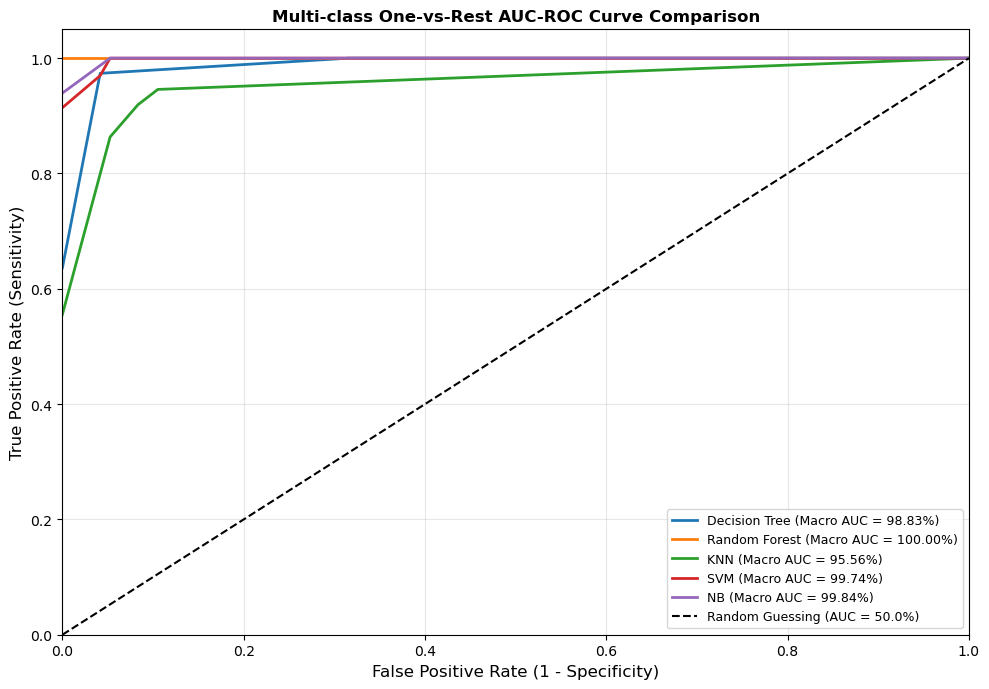

In [162]:
model_objects = {
    'Decision Tree': best_dt_m, 
    'Random Forest': best_rf_m, 
    'KNN': best_knn_m, 
    'SVM': best_svm_m,
    'NB': best_nb_m
}

# ovr 
y_test_bin = label_binarize(data.y_test, classes = np.unique(data.y_test))
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 7))

# models using scaled data
for model_name, model_obj in model_objects.items():
    if model_name in ["SVM", "KNN"]:
        X_test_processed = data.X_test_scaled
    else:
        X_test_processed = data.X_test
# probability scores accounting for scaled predictors
    y_prob = model_obj.predict_proba(X_test_processed)
#dictionaries    
    fpr_dict = {}
    tpr_dict = {}
    
    # ROC per class
    for i in range(n_classes):
        fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        
    # Aggregate
    all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(n_classes)]))
    # create grid for unique fpr
    mean_tpr = np.zeros_like(all_fpr)
    # interpolate to get the clean Macro-Average line tpr
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
    mean_tpr /= n_classes
    
    macro_auc = auc(all_fpr, mean_tpr)

#plot
    plt.plot(all_fpr, mean_tpr, label=f'{model_name} (Macro AUC = {macro_auc*100:.2f}%)', lw=2)

# baseline
plt.plot([0, 1], [0, 1], 'k--', lw= 1.5, label='Random Guessing (AUC = 50.0%)') # blac_k line


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Multi-class One-vs-Rest AUC-ROC Curve Comparison', fontsize=12, fontweight='bold')
plt.legend(loc="lower right", fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
